In [49]:
import logging
from multiprocessing.spawn import get_command_line
from operator import ge

from scipy.sparse import csc_matrix 
from scipy.sparse.linalg import spsolve
from scipy.optimize import lsq_linear
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np
from copy import deepcopy
import regpy.stoprules as rules
from numpy.core.numeric import ones_like
from regpy.vecsps import UniformGridFcts, DirectSum
from regpy.hilbert import L2, Sobolev, Hm0Domain
import regpy.hilbert as hilbert
from regpy.operators import Operator, SquaredModulus, PtwMultiplication, VectorOfOperators
from regpy.operators import CoordinateProjection, Identity, InnerShift, OuterShift
from regpy.operators import DirectSum as opDirectSum
from regpy.operators.pinem import get_op_g_to_data, get_op_complex_g_to_data
from regpy.solvers import HilbertSpaceSetting
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.solvers.nonlinear.newton import NewtonCG
from scipy.io import loadmat, savemat
from scipy.misc import ascent
from numpy.linalg import norm
from regpy.util.ImShowFig import ImShowFig

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)


### conversion of complex numbers to RGB values for plotting g

In [64]:
def complex_to_rgb_log(z):
    HSV = np.dstack( (np.mod(np.angle(z)/(2.*np.pi),1), 1.0*np.ones(z.shape), np.log(np.abs(z))/np.max(np.log((np.abs(z[:])))), ))
    return hsv_to_rgb(HSV)

def complex_to_rgb(z):
    HSV = np.dstack( (np.mod(np.angle(z)/(2.*np.pi),1), 1.0*np.ones(z.shape), np.abs(z)/np.max((np.abs(z[:]))), ))
    return hsv_to_rgb(HSV)

In [4]:
class FixAmplitude(Operator):
    # Operator (a,phase) |-> (ampl, phase) for some fixed ampl
    # (This could be replaced by the operator phase |-> (ampl, phase), but this would
    # require more if statements in main.)
    def __init__(self, ampl, domain):
        self.ampl = ampl
        super().__init__(DirectSum(domain, domain), DirectSum(domain, domain))

    def _eval(self, x, differentiate):
        _, phase = self.domain.split(x)
        return self.codomain.join(self.ampl, phase)

    def _derivative(self, x):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(0*ampl, phase)

    def _adjoint(self, x):
        ampl, phase = self.codomain.split(x)
        return self.domain.join(0*ampl, phase)

In [5]:
class FixPartsOfAmplitudeAndPhase(Operator):
    # Operator (ampl|_mask_a,phase|_mask_p) |-> (E(ampl|_mask_a)+prior_ampl, E(phase|_mask_p)+prior_phase) 
    # for some prior guess prior_ampl, prior_phase of amplitude and phase, masks (mask_a,mask_p)
    # for the regions where phase and amplitude are supposed to be reconstructed/improved. 
    # E extends functions by 0 
    def __init__(self, prior_ampl, prior_phase,mask_a,mask_p,domain):
        self.prior_ampl = prior_ampl
        self.prior_phase = prior_phase
        self.proj_a = CoordinateProjection(domain,mask_a)
        self.proj_p = CoordinateProjection(domain, mask_p)
        self.ext_a = self.proj_a.adjoint
        self.ext_p = self.proj_p.adjoint
        super().__init__(DirectSum(self.proj_a.codomain, self.proj_p.codomain), 
            DirectSum(domain, domain))

    def _eval(self, x, differentiate):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(self.ext_a(ampl)+self.prior_ampl, 
             self.ext_p(phase)+self.prior_phase)

    def _derivative(self, x):
        ampl, phase = self.domain.split(x)
        return self.codomain.join(self.ext_a(ampl), self.ext_p(phase))

    def _adjoint(self, x):
        ampl, phase = self.codomain.split(x)
        return self.domain.join(self.proj_a(ampl), self.proj_p(phase))


def ampphase2complex(amp, phase):
    return amp * np.exp(1j * phase)


In [6]:
def harmonic_extension(mask, values, damping = 0):
    # harmonic extension of a function on part of a 2D regular grid  
    # input: 
    #     mask: binary mask with True at point where values are given.
    #           At the boundary mask must have values True.
    #     values: array of function values: only values at points where mask=True are relevant
    #     damping: The extension satisfies (-Delta + damping)u =0, so only for the default 
    #              damping = 0 the extension is harmonic. 
    #              damping >0 may be used to create initial guesses for synthetic data generated with damping=0.  
    # 
    # output:
    #     An array u which coincides with values at {mask=True}, and an approximation of a 
    #     harmonic function on {mask=False} which is globally continuous
    #   
    u = values.flatten()
    G = np.where(mask,0,1) # boolean to integer
    k_int = np.nonzero(G)  # integer coordinates of interior points
    k_ext = np.nonzero(1-G) # integer coordinates of exterior points
    G[k_int] = 1+np.arange(len(k_int[0]))

    G1 = G.flatten()
    [m,n] = G.shape
    # Indices of interior points
    p = np.where(G1)[0] # list of numbers of interior points in flattened array
    N = len(p)
    f = np.zeros((N,),dtype=u.dtype) # right hand side of matrix equation 

    # Connect interior points to themselves with 4's.
    i = G1[p]-1
    j = G1[p]-1
    s = (damping/(m*n) + 4.)*np.ones(p.shape)

    # for k = north, east, south, west
    for k in [-1, n, 1, -n]:
        # Possible neighbors in k-th direction
        Q = G1[p+k]
        # Index of points with interior neighbors in k-th direction
        q = np.where(Q)[0]
        q_ext = np.where(Q==0)[0]
        # Connect interior points to neighbors with -1's.
        i = np.concatenate([i, G1[p[q]]-1])
        j = np.concatenate([j,Q[q]-1])
        s = np.concatenate([s,-np.ones(q.shape)])
        i_ext = G1[p[q_ext]]-1
        f[i_ext] = f[i_ext]+u[p[q_ext]+k]
    # sparse matrix with 5 diagonals
    negLap= csc_matrix((s, (i,j)),(N,N))
    u = values.copy()
    u[k_int]=spsolve(negLap,f)
    return u

In [7]:
def load_experimental_data_2(filename):
    mat = loadmat(filename)
    g_map = mat['pm']['g_map'][0][0]
    mask = mat['pm']['mask'][0][0]
    mask_binary = mat['pm']['mask_binary'][0][0].astype(dtype=bool)
    px_size = mat['pm']['px_sizes'][0][0]
    px_size = px_size * 1e-9 #convert nm to m
    return g_map, mask, mask_binary, px_size


In [8]:
def simulated_data(complex_g=True,amplitude_known=1, parallel=True,list_of_filters=None,N=30):
    filename = r"./data/FresnelPinemMap_obj_javier_2.mat"
    g_map, mask, mask_binary, px_size = load_experimental_data_2(filename)
    fov = tuple(x*px_size for x in mask.shape)
    lambda_electron = 2.51e-12
    defocus = 900e-6
    fresnel_number = np.prod(fov)/(defocus * lambda_electron)
    # Uniform grid
    N1,N2 = mask.shape
    a_psi0_multiplier = mask.astype(complex)
    boundary_mask = np.zeros_like(mask_binary)
    boundary_mask[0,:]=True; boundary_mask[-1,:]=True
    boundary_mask[:,0]=True; boundary_mask[:,-1]=True
    mask_binary = mask_binary & ~boundary_mask

    grid = UniformGridFcts(np.linspace(0, 1, N1, endpoint=False),
                           np.linspace(0, 1, N2, endpoint=False))
    if complex_g:
        op = get_op_complex_g_to_data(grid, fresnel_number, mask_binary,a_psi0_multiplier, 
            list_of_filters = list_of_filters,
            N=N, 
            parallel=parallel
        )
        if amplitude_known==1:
            op2 = PtwMultiplication(grid,1.0*mask_binary) * SquaredModulus(grid.complex_space())
            op = VectorOfOperators([op2, op])
        return op, grid, g_map, g_map, mask_binary, ~boundary_mask
    else:
        op = get_op_g_to_data(grid, fresnel_number, mask_binary, a_psi0_multiplier, 
                    list_of_filters = list_of_filters,
                    N=N,
                    parallel=parallel
                    )
        if amplitude_known==1:
            ampl_fix = FixAmplitude(np.abs(g_map), grid)
            op = op * ampl_fix
        exact_solution = op.domain.join(np.abs(g_map),
                                        np.unwrap(np.angle(g_map.T)).T)

        return op, grid, exact_solution, g_map, mask_binary, ~boundary_mask


In [9]:
def synthetic_data(complex_g=True, amplitude_known=1, parallel=True):
    # Example parameters
    fresnel_number = 5e3    # Fresnel-number of the simulated imaging system, associated with the unit-lengthscale
    # in grid (i.e. with the size of one pixel for the above choice of grid)
    # noise_level = 0.0001      # Noise level in the simulated data

    N = 8
    # define grid
    Xdim = 256
    Y_dim = 256
    grid = UniformGridFcts(np.linspace(0, 1, Xdim, endpoint=False),
                       np.linspace(0, 1, Y_dim, endpoint=False))

    # define forward operator and its domain
    [Xco, Yco] = np.meshgrid(np.arange(-1, 1, 2/Xdim), np.arange(-1, 1, 2/Y_dim))
    mask_p = (abs(Xco+0.2) <= 0.2) & (abs(Yco) <= 0.4)
    mask_p = mask_p | (abs((Xco-0.35)*(Xco-0.35)+(Yco-0.35)*(Yco-0.35)) <= 0.01)

    mask = (abs(Xco)<=0.8) & (abs(Yco)<=0.8)
    a_psi0_multiplier = np.ones(grid.shape, complex)

    # Create phantom image (= padded example-image)
    picture = ascent()
    g_map_amp = picture[-Xdim//2:, -Y_dim//2:].astype(np.float64)/255
    g_map_amp *= 2
    g_map_phase = picture[:Xdim//2, :Y_dim//2].astype(np.float64)/255
    g_map_phase *= 0.5*np.pi
    pad_amount = tuple([(grid.shape[0] - g_map_amp.shape[0])//2,
                       (grid.shape[1] - g_map_amp.shape[1])//2])
    g_map_amp = np.pad(g_map_amp, pad_amount, 'constant', constant_values=0)
    g_map_phase = np.pad(g_map_phase, pad_amount, 'constant', constant_values=0)
    g_map_phase = harmonic_extension(~mask | mask_p, g_map_phase*mask)
    g_map_amp = harmonic_extension(~mask | mask_p, g_map_amp*mask)
    g_map = ampphase2complex(g_map_amp, g_map_phase)
    # g_map /= 10*abs(g_map).max()
    # g_map += ones_like(g_map)
    g_map = g_map.astype(complex)*mask

    if complex_g:
        op = get_op_complex_g_to_data(grid, fresnel_number, mask,
                                     a_psi0_multiplier, N=N, parallel=parallel)
        if amplitude_known==1:
            op2 = SquaredModulus(grid.complex_space()) - np.abs(g_map)**2
            op = VectorOfOperators([op2, op])
    else:
        op = get_op_g_to_data(grid, fresnel_number, mask, a_psi0_multiplier, N=N, parallel=True)
        if amplitude_known==1:
            ampl_fix = FixAmplitude(np.abs(g_map), grid)
            op = op * ampl_fix

    if complex_g:
        exact_solution = g_map
    else:
        exact_solution = op.domain.join(np.abs(g_map), np.angle(g_map))
    return op, grid, exact_solution, g_map, mask & ~mask_p, mask_p


### set parameters and initialize forward operator

In [52]:
output_filename = 'test'
real_data = True
complex_g = True
## amplitude_known == 0 -> no prior knowledge of amplitude
# amplitude_known == 1 -> prior knowledge of amplitude everywhere
# amplitude_known == -1 -> prior knowledge of amplitude only on mask_a
amplitude_known = 1
polynomial_basis = False
intensity = 1e6  
intensity_mod = 2e6  # intensity for measurements of modulus
if real_data:
    op, grid, exact_solution, g_map, mask_a, mask_p \
        = simulated_data(complex_g=complex_g, amplitude_known=amplitude_known,
        list_of_filters= [ [1,3,5,7],[-1,-3,-5,-7]],
        #N=8,
        parallel=True)
    # regpar = 5e-2; sobolev_index = 2
    sobolev_index = 1
    if complex_g:
        regpar = 1e-10; regpar_step = 1/2
    else:
        regpar = 1e-10; regpar_step = 1/2
else:
    op, grid, exact_solution, g_map, mask_a, mask_p \
        = synthetic_data(complex_g=complex_g, amplitude_known=amplitude_known)
    if amplitude_known == -1:
        regpar = 1e-6 
    else:
        regpar = 5e-4
    sobolev_index = 1
    regpar_step = 1/3

if complex_g:
    # h_domain = Sobolev(grid.complex_space(), index=sobolev_index)
    h_domain = Hm0Domain(mask_p, dtype=complex, index = sobolev_index)
    g0 = harmonic_extension(1-mask_p,g_map)
    proj = CoordinateProjection(grid.complex_space(),mask_p)
    projection = InnerShift(proj,g0)
    extension = OuterShift(proj.adjoint,g0)
else:
    ## for global Sobolev norm
    # h_domain = 0.5 * Sobolev(grid, index=sobolev_index) + L2(grid)  # Sobolev(grid, index=0.5)
    if amplitude_known == 1:
        if polynomial_basis:
            coeff_grid = UniformGridFcts(np.arange(pol_degrees[0]),np.arange(pol_degrees[1]))
            Bas =  legendre_basis(coeff_grid,grid)                
            h_domain = L2(grid) + L2(coeff_grid)
            extension = opDirectSum(Identity(grid),Bas)
            projection = extension.adjoint
        else:
            h_domain = L2(grid) + Hm0Domain(mask_p, index = sobolev_index)  
            projection = opDirectSum(Identity(grid),CoordinateProjection(grid,mask_p)) 
            extension = projection.adjoint
    if amplitude_known == -1: 
        h_domain = Hm0Domain(mask_a, index = sobolev_index) + Hm0Domain(mask_p, index = sobolev_index)
if amplitude_known == 1:
    # as extension is also needed for plotting, a copy is required to avoid errors 
    # on the use of revoked copies 
    extension2 = deepcopy(extension)
    op_ext = op * extension2
if amplitude_known == -1 and not complex_g:
    prior_ampl = harmonic_extension(~mask_a,np.abs(g_map),damping =400)
    prior_phase = harmonic_extension(~mask_p,np.unwrap(np.angle(g_map.T)).T,damping =0)
    extension = FixPartsOfAmplitudeAndPhase(prior_ampl,prior_phase, \
        mask_a, mask_p, grid)
    _,deriv = extension.linearize(extension.domain.zeros())
    projection = deriv.adjoint

    extension2 = deepcopy(extension)
    #extension2 = FixPartsOfAmplitudeAndPhase(abs(g_map) * (~mask_a),np.zeros(grid.shape), \
    #    mask_a, mask_p, grid)
    op_ext = op * extension2



### generate synthetic data and define setting

In [24]:
flat_codomain = DirectSum(*op.codomain.summands, flatten=True)
if complex_g and amplitude_known==1:
    exact_data = op(exact_solution)
    #exact_data = op_ext(projection(exact_solution))
    exact_data_comp = op.codomain.split(exact_data)
    noisy_data0 = np.random.poisson(intensity_mod * exact_data_comp[0])/intensity_mod
    noisy_data1 = np.random.poisson(intensity * exact_data_comp[1])/intensity
    data = op.codomain.join(noisy_data0, noisy_data1)
    h_codomain0 = L2(grid, weights=1e-7*(1+intensity_mod*exact_data_comp[0])/intensity_mod)
    data_comp = flat_codomain.split(data)
    h_codomain1 = L2(grid, weights=(1+intensity*data_comp[1])/intensity)
    for j in range(2, len(flat_codomain)):
        h_codomain1 = h_codomain1 + L2(grid, weights=(1+intensity*data_comp[j])/intensity)
    h_codomain = hilbert.DirectSum(h_codomain0, h_codomain1)
else:
    exact_data = op(exact_solution)
    #if amplitude_known = 0: 
    #    exact_data = op_ext(projection(exact_solution))
    #elif amplitude_known = -1: 
    #    exact_data = op_ext(projection(exact_solution-))
    data = np.random.poisson(intensity * exact_data)/intensity
    data_comp = op.codomain.split(data)
    # define codomain Gram matrix based on observed data to approximate log-likelihood
    h_codomain = L2(grid, weights=(1+intensity*data_comp[0])/intensity)
    for j in range(1, len(data_comp)):
        h_codomain = h_codomain + L2(grid, weights=(1+intensity*data_comp[j])/intensity)
setting = HilbertSpaceSetting(op=op_ext, h_domain=h_domain, h_codomain=h_codomain)

### set up initial guess

In [14]:
if real_data:
    angle = np.deg2rad(10)
    X, Y = np.meshgrid(np.linspace(0, 1, np.size(mask_a, 1)), np.linspace(0, 1, np.size(mask_a, 0)))
    init_phase_gradient = -1 * (np.sin(angle)*X + np.cos(angle)*Y) * 2*np.pi * 3 + 2.5
if complex_g:
    if amplitude_known==1:
        init_vec = harmonic_extension(1-mask_a,mask_a * abs(g_map) * np.exp(j*init_phase_gradient))
    else:
        init_vec = grid.complex_space().ones() * mask_a
else:
    if amplitude_known==1:
        # init_vec = op.domain.join(np.abs(g_map), \
        #         norm(np.angle(g_map).ravel(),1)/norm(mask.ravel(),1) * mask)
        if polynomial_basis:
            T = Bas.as_linear_operator()
            init_phase = lsq_linear(T,grid.flatten(init_phase_gradient)).x
            init_vec_proj =  op_ext.domain.join(np.abs(g_map),Bas.domain.fromflat(init_phase))
        else:
            init_vec = op.domain.join(np.abs(g_map),init_phase_gradient * mask_p)
    elif amplitude_known == 0:
        # init_vec = op.domain.join(mask, \
        #     norm(np.angle(g_map).ravel(),1)/norm(mask.ravel(),1) * mask)
        init_vec = op.domain.join(mask_a.astype(dtype=np.float),
                                    init_phase_gradient * mask_p)
    else:
        init_vec = op.domain.join(np.zeros_like(prior_ampl),
                                    np.zeros_like(prior_phase))
# init_vec_proj = init_vec
if not polynomial_basis:
    init_vec_proj = projection(init_vec)

### define regularization method

In [15]:
if complex_g and not amplitude_known:
    data_comp = flat_codomain.split(data)
    nr_data = len(data_comp)
    sqrtdata = flat_codomain.join([np.sqrt(data_comp[0]/intensity_mod),
        *[np.sqrt(data_comp[k]/intensity) for k in range(1,nr_data)]])
else:
    sqrtdata = np.sqrt(data/intensity) 
stoprule = (
    rules.Discrepancy(
        setting.h_codomain.norm,
        data,
        noiselevel= setting.h_codomain.norm(sqrtdata),
        tau=1.0
    ) +
    rules.CountIterations(max_iterations=12,while_type=True) 
)
#    solver = NewtonCG(
#        setting, data, init=init_vec_proj,
#        cgmaxit=50, rho=0.9
#    )
solver = IrgnmCG(
    setting, data, init=init_vec_proj,
    regpar=regpar, regpar_step=regpar_step,
    inner_it_logging_level=logging.INFO
    )



### computation of reconstruction errors

In [16]:
def reconstruction_error(_exact, _reconstruction):
    def fnorm(arr):
        return norm(arr[:])

    # nonlocal complex_g
    # nonlocal mask_a
    # nonlocal mask_p
    if complex_g:
        reco_error1 = fnorm((np.abs(_reconstruction)-np.abs(_exact)))/fnorm(_exact)
        ex_phase = np.unwrap(np.angle(_exact.T)).T
        reco_phase = np.unwrap(np.angle(_reconstruction.T)).T
        reco_error2 = fnorm(np.exp(1j*reco_phase)-np.exp(1j*ex_phase))/np.sqrt(np.prod(_exact.shape))
        reco_error3 = fnorm(_reconstruction-_exact)/fnorm(_exact)
    else:
        ex_amp, ex_phase = op.domain.split(_exact)
        reco_amp, reco_phase = op.domain.split(_reconstruction)
        reco_error1 = fnorm(reco_amp-ex_amp)/fnorm(ex_amp)
        #reco_error2 = norm(mask_p*(reco_phase-ex_phase))/fnorm(mask_p*ex_phase)
        reco_error2 = fnorm(np.exp(1j*reco_phase)-np.exp(1j*ex_phase))/np.sqrt(np.prod(ex_phase.shape))
        # fnorm((reco_phase-ex_phase))/fnorm(ex_phase)
        reco_error3 = fnorm(reco_amp*np.exp(1j*reco_phase) -ex_amp*np.exp(1j*ex_phase))/fnorm(ex_amp)
    return reco_error1, reco_error2, reco_error3

In [36]:
def plot_reco(fig1,fig2,reco_amp,reco_phase,reco_data_comp,g_map,ex_data_comp,newton_step):
    plot_data = []
    if amplitude_known==1 and not complex_g:
        plot_data.append({'pos': (0, 0), 'data': np.abs(reco_amp*np.exp(1j*reco_phase)-g_map).T,
                            'title': '| |g_rec|*exp(i arg(g_rec))- g|, step {}'.format(newton_step)})
        plot_data.append({'pos': (1, 0), 'data': np.abs(g_map.T),
                            'title': '|g|, step {}'.format(newton_step)})
    else:
        plot_data.append({'pos': (1, 0), 'data': reco_amp.T,
                        'title': 'Reco |g|, step {}'.format(newton_step)})
        plot_data.append({'pos': (2, 0), 'data': reco_amp.T-np.abs(g_map.T),
                            'title': 'Error |g|, step {}'.format(newton_step)})
    plot_data.append({'pos': (1, 1), 'data': complex_to_rgb(reco_amp.T*np.exp(1j*reco_phase.T)),
                    'title': 'g_rec, step {}'.format(newton_step)})
    plot_data.append({'pos': (2, 1), 'data': np.abs(np.exp(1j*reco_phase.T)-(g_map/(np.abs(g_map)+1e-16)).T),
                            'title': '|g_rec/|g_rec|-g/|g||, step {}'.format(newton_step)})
    #plot_data.append({'pos': (2, 1), 'data': (np.abs(g_map.T)>=0.1)*(reco_phase.T-np.unwrap(np.angle(g_map.T))),
    #                    'title': 'arg(g_rec)-arg g, step {}'.format(newton_step)})
    fig1.plot(plot_data)

    plot_data = [{'pos': (1, j), 'data': reco_data_comp[j].T,
                    'title':'rec. data step {}'.format(newton_step)}
                for j in range(nr_data)]
    for j in range(nr_data):
        plot_data.append({'pos': (2, j), 'data': reco_data_comp[j].T-ex_data_comp[j].T,
                        'title': 'diff'})
    fig2.plot(plot_data)

### plot exact solution and exact data

2023-03-05 16:50:20,047 WARNING matplotlib.image     :: Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


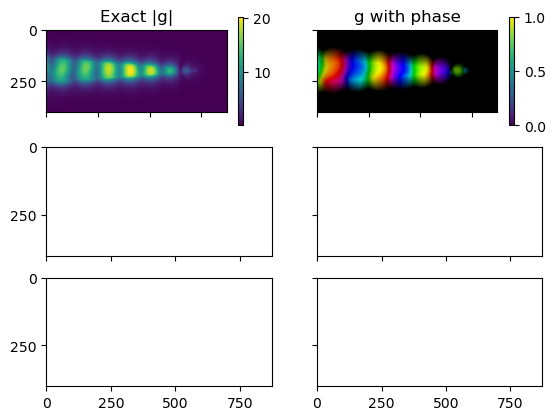

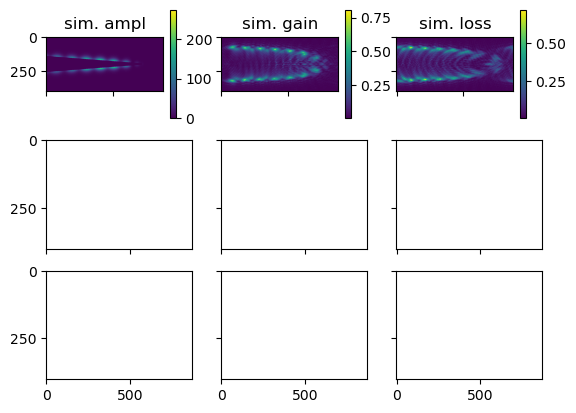

2023-03-05 16:50:28,474 INFO root                 :: rel. reconstruction errors step 0: modulus: 1.0000, phase: 889.3789, norm: 0.9991


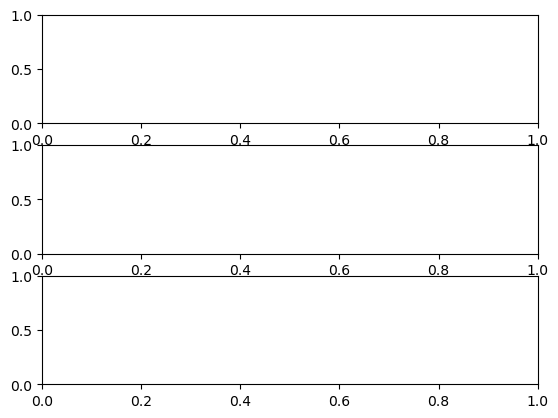

In [59]:
if not complex_g:
    ex_abs, ex_phase = op.domain.split(exact_solution)
else:
    ex_abs = np.abs(g_map)
    ex_phase = np.unwrap(np.angle(g_map.T)).T
fig1 = ImShowFig(3, 2)
plot_data1 = [{'pos': (0, 0), 'data': np.abs(g_map.T), 'title': 'Exact |g|'},
             {'pos': (0, 1), 'data': complex_to_rgb_log(g_map.T), 'title': 'g with phase'}]
fig1.plot(plot_data1)

data_comp = flat_codomain.split(data)
nr_data = len(data_comp)
fig2 = ImShowFig(3, nr_data)
plot_data2 = [{'pos': (0, j), 'data': data_comp[j].T, 'title':'sim. data'}
                for j in range(nr_data)]
if nr_data ==3:
    plot_data2[0]['title'] = 'sim. ampl'
    plot_data2[1]['title'] = 'sim. gain'
    plot_data2[2]['title'] = 'sim. loss'

#plot_data2.append(
#    {'pos': (0, nr_data), 'data': data_comp[nr_data-1]-data_comp[nr_data-2], 'title': 'sim. gain-loss'})

fig2.plot(plot_data2)

if hasattr(solver, "nr_inner_its"):
    fig3, axs3 = plt.subplots(3, 1, sharex=False, sharey=False)
else:
    fig3, axs3 = plt.subplots(2, 1, sharex=False, sharey=False)

stats = {'ampl_err': [], 'phase_err': [], 'complex_err': [], 'residuals': [], 'nr_inner_steps': []}
plot_write_safe(solver.x,solver.y,fig1,fig2,axs3,0,
    do_plottings=True,stats=stats,output_filename= output_filename)

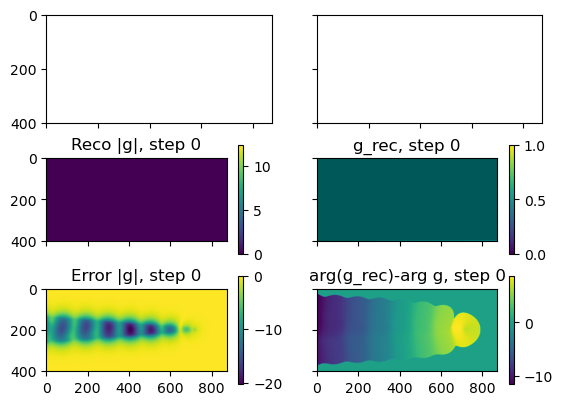

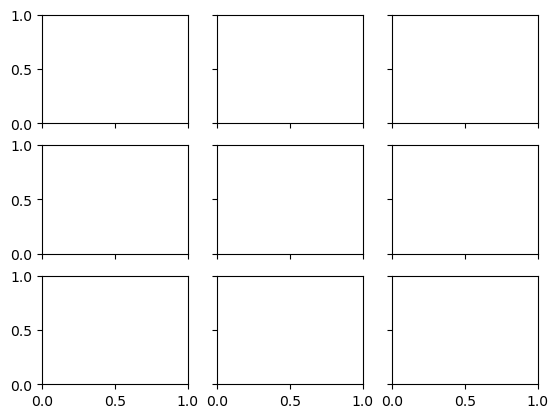

In [37]:
fig3 = ImShowFig(3,2)
fig4 = ImShowFig(3,3)
plot_reco(fig3,fig4,reco_amp,reco_phase,reco_data_comp,g_map,ex_data_comp,0)


In [57]:
def plot_write_safe(reco,reco_data,fig1,fig2,axs3, newton_step,
    do_plottings=True, stats =None,output_filename = 'test'
    ):

    # fix unidentified constant global phase 
    if complex_g:
        ex_phase = np.unwrap(np.angle(exact_solution.T)).T
        reco_phase = np.unwrap(np.angle(ereco.T)).T
        reco_amp = np.abs(ereco)
    else:
        _, ex_phase = op.domain.split(exact_solution)
        reco_amp, reco_phase = op.domain.split(ereco)
    phase_correction = np.median(ex_phase[~mask_a])-np.median(reco_phase[~mask_a]) 
    reco_phase += phase_correction
    if complex_g:
        ereco = reco_amp * np.exp(1j*reco_phase)
    else:
        ereco = op.domain.join(reco_amp,reco_phase)
        
    reco_error1, reco_error2, reco_error3 = reconstruction_error(exact_solution, ereco)
    logging.info('rel. reconstruction errors step {}: modulus: {:1.4f}, phase: {:1.4f}, norm: {:1.4f}'.format(
        newton_step, reco_error1, reco_error2, reco_error3))
    stats['ampl_err'].append(reco_error1)
    stats['phase_err'].append(reco_error2)
    stats['complex_err'].append(reco_error3)
    stats['residuals'].append(setting.h_codomain.norm(reco_data-exact_data))
    if hasattr(solver, "nr_inner_its") and callable(solver.nr_inner_its):
        stats['nr_inner_steps'].append(solver.nr_inner_its())

    savemat('./PINEM_tests/'+output_filename+'{}.mat'.format(newton_step),
        {'reco_amp':reco_amp, 'reco_phase': reco_phase, 'stats': stats}
    )

    reco_data_comp = flat_codomain.split(reco_data)
    ex_data_comp = flat_codomain.split(data)

    if do_plottings:
        plot_reco(fig1,fig2,reco_amp,reco_phase,reco_data_comp,g_map,ex_data_comp,newton_step)
        axs3[0].cla()
        if not amplitude_known==1:
            axs3[0].plot(stats['ampl_err']/stats['ampl_err'][0], label='amplitude error')
        axs3[0].plot(stats['phase_err']/stats['phase_err'][0], label='phase error')
        axs3[0].plot(stats['complex_err']/stats['complex_err'][0], label='complex error')
        axs3[0].legend()
        axs3[1].cla()
        axs3[1].semilogy(stats['residuals'], label='residuals')
        axs3[1].legend()
        if hasattr(solver, "nr_inner_its") and callable(solver.nr_inner_its):
            axs3[2].cla()
            axs3[2].plot(stats['nr_inner_steps'], label='number of inner CG steps')
            axs3[2].legend()
        plt.show(block=False)
        plt.pause(0.1)

2023-03-05 16:52:57,321 INFO root                 :: rel. reconstruction errors step 0: modulus: 1.0000, phase: 889.3789, norm: 0.9991


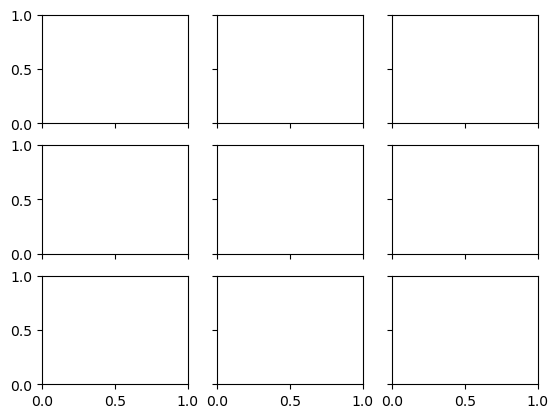

In [62]:
 stats = {'ampl_err': [], 'phase_err': [], 'complex_err': [], 'residuals': [], 'nr_inner_steps': []}
solver._nr_inner_steps=0
fig4 = ImShowFig(3,3)
plot_write_safe(solver.x,solver.y,fig1,fig4,axs3,newton_step,
    do_plottings=~stoprule.triggered,stats=stats,output_filename= output_filename)

In [63]:
disc =stoprule[0].
print(x)
#reco, reco_data = solver.next()

[1]
